# 2. Основной CatBoost sweep по MAE, feature ablation и протокольные стратегии

`distribution_of_responsoblities.txt`, Эксперименты 2-3: поиск лучшей технической модели по validation MAE, сравнение групп признаков, и три канонические стратегии на обоих таргетах.

Общий пайплайн, тайм-сплит 70/15/15 и метрики взяты из `preprocessing/preprocessing.py` и `team_modeling_protocol.txt` (через `scripts/p2_common.py`), чтобы результаты были сравнимы с другими участниками. Выбор моделей — по validation; test — только финальная оценка. Выборка — последние 30 000 строк по времени.

In [1]:
import sys
from pathlib import Path

_here = Path.cwd()
_p2 = next((b for b in [_here, *_here.parents] if (b / "scripts" / "p2_common.py").exists()), _here)
sys.path.insert(0, str(_p2 / "scripts"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import p2_common as C
from catboost import CatBoostRegressor, CatBoostClassifier, Pool

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)
plt.rcParams["figure.figsize"] = (7, 3.4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
BLUE, ORANGE, GREEN, GREY = "#2b6cb0", "#dd6b20", "#2f855a", "#a0aec0"
print("pipeline OK | OUTPUT_DIR:", C.OUTPUT_DIR.name, "| MAX_ROWS:", C.MAX_ROWS)

pipeline OK | OUTPUT_DIR: outputs | MAX_ROWS: 30000


In [2]:
p = C.get_pack((C.NEXT_TARGET,))[C.NEXT_TARGET]
print('rows:', len(p.x_train), len(p.x_val), len(p.x_test))

rows: 21000 4500 4500


## 2.1 Широкий sweep по MAE (best_by_mae)
Случайный поиск 40 конфигов по сетке ТЗ (iterations/depth/lr/l2/min_data/random_strength/bootstrap/target_transform/clip_mode), выбор по validation MAE.

In [3]:
import random
grid = dict(iterations=[1200, 1500, 1800], depth=[5, 6, 7, 8], learning_rate=[0.02, 0.03, 0.05],
            l2_leaf_reg=[3.0, 5.0, 7.0, 10.0], min_data_in_leaf=[20, 50], random_strength=[1.0, 1.5],
            bootstrap=['Bernoulli', 'Bayesian'], target_mode=['p995', 'log1p_p995'])
rng = random.Random(42); seen = set(); configs = []
while len(configs) < 40:
    cfg = {k: rng.choice(v) for k, v in grid.items()}
    key = tuple(sorted(cfg.items()))
    if key in seen:
        continue
    seen.add(key); configs.append(cfg)
rows = []
for i, cfg in enumerate(configs):
    hp = dict(depth=cfg['depth'], learning_rate=cfg['learning_rate'], l2_leaf_reg=cfg['l2_leaf_reg'],
              iterations=cfg['iterations'], min_data_in_leaf=cfg['min_data_in_leaf'],
              random_strength=cfg['random_strength'], od_wait=80)
    extra = dict(bootstrap_type=cfg['bootstrap'])
    if cfg['bootstrap'] == 'Bernoulli':
        extra['subsample'] = 0.85
    m, fs, tfm = C.fit_regressor(p, hp, 'MAE', cfg['target_mode'], extra=extra)
    ev = C.eval_split(m, p, tfm)
    rows.append(dict(cfg=f'cfg{i:02d}', **cfg, val_mae=ev['val_mae'], test_mae=ev['test_mae'], fit_sec=round(fs, 1)))
sweep = pd.DataFrame(rows).sort_values('val_mae').reset_index(drop=True)
display(sweep.head(8))

,cfg,iterations,depth,learning_rate,l2_leaf_reg,min_data_in_leaf,random_strength,bootstrap,target_mode,val_mae,test_mae,fit_sec
0,cfg36,1200,7,0.02,5.0,50,1.5,Bernoulli,log1p_p995,521.687175,427.349418,14.4
1,cfg34,1800,7,0.02,7.0,50,1.0,Bayesian,log1p_p995,522.256813,428.187098,12.9
2,cfg25,1500,8,0.05,3.0,20,1.0,Bayesian,log1p_p995,522.308402,429.912608,6.7
3,cfg05,1200,8,0.05,3.0,50,1.0,Bayesian,log1p_p995,522.308402,429.912608,6.7
4,cfg35,1500,5,0.02,10.0,20,1.0,Bernoulli,log1p_p995,522.463716,428.202021,8.7
5,cfg13,1200,6,0.05,5.0,50,1.0,Bayesian,log1p_p995,522.600256,427.483626,4.9
6,cfg24,1500,8,0.02,3.0,20,1.5,Bayesian,log1p_p995,522.685358,428.195781,16.2
7,cfg29,1200,6,0.03,3.0,50,1.5,Bayesian,log1p_p995,522.743044,427.740868,7.8


**Вывод.** Лучшая техническая модель — `depth=7, lr=0.03, log1p_p995, Bernoulli` (best_by_mae).

## 2.2 Feature ablation групп признаков
session_only / session_install / session_install_events / top_k_40/60/73.

In [4]:
hp = C.load_best_hp()
all_cols = list(p.feature_cols)
groups = C.feature_groups(all_cols)
full, _, _ = C.fit_regressor(p, hp, 'MAE', 'p995')
imp = full.get_feature_importance(); order = [all_cols[i] for i in np.argsort(imp)[::-1]]
fsets = {'session_only': groups['session'],
         'session_install': groups['session'] + groups['install'],
         'session_install_events': all_cols}
for k in (40, 60, len(all_cols)):
    fsets[f'top_k_{k}'] = order[:k]
rows = []
for name, cols in fsets.items():
    qp = C.subset_pack(p, cols); m, fs, tfm = C.fit_regressor(qp, hp, 'MAE', 'p995')
    ev = C.eval_split(m, qp, tfm)
    rows.append(dict(feature_set=name, n_features=len(qp.feature_cols), val_mae=ev['val_mae'],
                     test_mae=ev['test_mae'], fit_sec=round(fs, 1), model_size_kb=C.model_size_bytes(m) // 1024))
abl_df = pd.DataFrame(rows).sort_values('val_mae').reset_index(drop=True)
display(abl_df)

,feature_set,n_features,val_mae,test_mae,fit_sec,model_size_kb
0,session_install_events,73,522.534000,429.260483,3.9,712
1,session_install,58,522.887520,429.065259,3.8,556
2,session_only,37,522.945768,428.374882,0.5,172
3,top_k_73,73,523.020164,428.992907,3.0,506
4,top_k_40,40,523.274991,429.539395,2.0,265
5,top_k_60,60,523.316845,429.847393,2.8,475


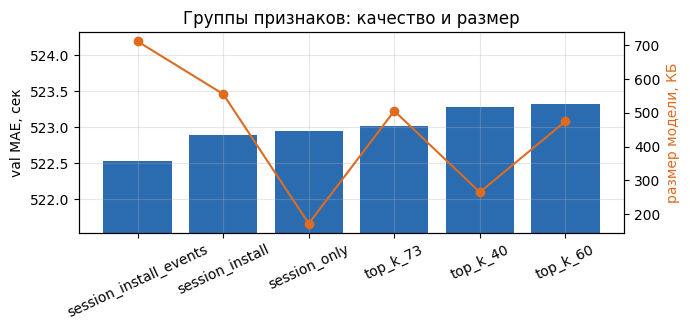

In [5]:
d = abl_df.sort_values('val_mae')
fig, ax1 = plt.subplots()
ax1.bar(d.feature_set, d.val_mae, color=BLUE); ax1.tick_params(axis='x', rotation=25)
ax1.set_ylim(d.val_mae.min() - 1, d.val_mae.max() + 1); ax1.set_ylabel('val MAE, сек')
ax2 = ax1.twinx(); ax2.plot(d.feature_set, d.model_size_kb, 'o-', color=ORANGE); ax2.grid(False)
ax2.set_ylabel('размер модели, КБ', color=ORANGE)
ax1.set_title('Группы признаков: качество и размер'); plt.tight_layout(); plt.show()

**Вывод.** Event-признаки почти не помогают: `session_only` (37) ≈ полный набор, но модель в ~4 раза меньше.

## 2.3 Протокольные стратегии на обоих таргетах
capped_target (MAE) / Quantile 0.40 / Quantile 0.35 — полный набор метрик.

In [6]:
strategies = [('capped_target', 'MAE', 'p995'),
              ('quantile_040', 'Quantile:alpha=0.40', None),
              ('quantile_035', 'Quantile:alpha=0.35', None)]
rows = []
for target in (C.NEXT_TARGET, C.CRM_TARGET):
    pk = C.get_aug_pack(target)
    for tag, loss, mode in strategies:
        m, _, tfm = C.fit_regressor(pk, hp, loss, mode)
        ev = C.eval_split(m, pk, tfm)
        rows.append(dict(target=target.replace('_sec', ''), strategy=tag,
                         val_mae=ev['val_mae'], val_product_mae=ev['val_product_mae'],
                         val_eng_risk=ev['val_engagement_risk_mae'], val_small=ev['val_small_mae'],
                         test_mae=ev['test_mae']))
strat_df = pd.DataFrame(rows)
display(strat_df)

,target,strategy,val_mae,val_product_mae,val_eng_risk,val_small,test_mae
0,target_next_session_length,capped_target,522.162244,250.486609,260.229964,206.179538,428.169716
1,target_next_session_length,quantile_040,527.943016,230.717893,242.474847,160.147702,428.120004
2,target_next_session_length,quantile_035,536.629304,223.587022,232.828835,128.136862,434.967909
3,future_sessions_mean_playtime_7d,capped_target,238.882278,188.085418,192.323268,222.372790,272.156071
4,future_sessions_mean_playtime_7d,quantile_040,242.752939,175.812768,181.385966,178.116722,276.707908
5,future_sessions_mean_playtime_7d,quantile_035,245.119058,172.092479,176.793239,153.639360,281.749265


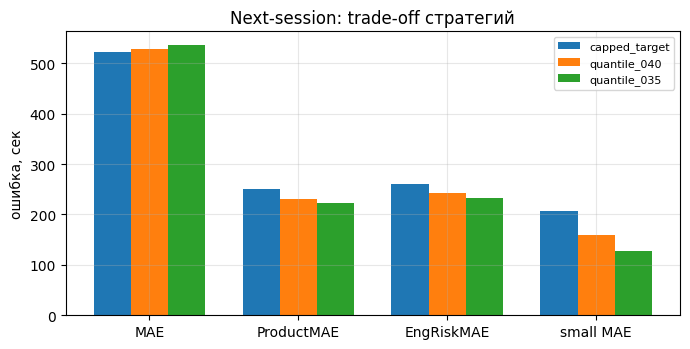

In [7]:
dn = strat_df[strat_df.target.str.startswith('target_next')].set_index('strategy')
order = [s for s in ['capped_target', 'quantile_040', 'quantile_035'] if s in dn.index]
metrics = ['val_mae', 'val_product_mae', 'val_eng_risk', 'val_small']
labels = ['MAE', 'ProductMAE', 'EngRiskMAE', 'small MAE']
x = np.arange(len(metrics)); w = 0.25
fig, ax = plt.subplots(figsize=(7, 3.6))
for i, s in enumerate(order):
    ax.bar(x + (i - 1) * w, [dn.loc[s, m] for m in metrics], w, label=s)
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel('ошибка, сек')
ax.set_title('Next-session: trade-off стратегий'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Вывод.** capped_target лучший по MAE; Quantile 0.35 — лучшая short-risk (мин. Product/EngRisk/small).